# trspam.csv ETL (Extract – Transform – Load)

Cleaning pipeline for the Turkish spam email dataset `trspam.csv`.

```
[Extract]     Parse raw CSV (handle malformed quotes)
    ↓
[Transform]   Restore control chars, normalize whitespace, remove HTML/boilerplate,
              drop empty texts, drop duplicates, encode labels
    ↓
[Load]        Save trspam_clean.csv / .parquet + train/valid/test
```

Raw data: `Text` (email body, may span multiple lines) / `Classification` (`spam` | `ham`)

## 0. Setup

In [1]:
%matplotlib inline

import re
import html
import quopri
from pathlib import Path

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

RAW_PATH = Path(r"C:\Users\USER\OneDrive\Desktop\[20.08.26] Light rain\00.turkish+spam\trspam.csv")
OUT_DIR  = RAW_PATH.parent
SEED     = 42

## 1. Extract

### Why can't we use `pd.read_csv` directly?

The body contains unescaped double quotes (`"`), which makes the standard CSV parser misinterpret field boundaries.

In [2]:
try:
    df_raw = pd.read_csv(RAW_PATH, encoding="utf-8")
    print(df_raw.shape)
except Exception as e:
    print(type(e).__name__ + ":", str(e).splitlines()[0])

ParserError: Error tokenizing data. C error: Expected 2 fields in line 8, saw 9


### Custom parser

By data structure, **each record's last line ends with `,spam` or `,ham`.**
We use this rule to split records line by line.

1. Remove the BOM (`\ufeff`) and the header row (`Text,Classification`)
2. A line ending with `,spam` / `,ham` → end of record
3. Keep newlines inside a record as part of the text

In [3]:
def extract_records(path: Path):
    lines = path.read_text(encoding="utf-8").lstrip("\ufeff").split("\n")
    if lines and set(lines[0].split(",")) >= {"Text", "Classification"}:
        lines = lines[1:]
    records, buf = [], []
    for line in lines:
        line = line.rstrip("\r")
        m = re.match(r"^(.*),(spam|ham)\s*$", line)
        if m:
            buf.append(m.group(1))
            records.append({"label": m.group(2), "text": "\n".join(buf).strip()})
            buf = []
        else:
            buf.append(line)
    return records

In [4]:
records = extract_records(RAW_PATH)
df = pd.DataFrame(records)
print("Records:", len(df))
df.head(3)

Records: 825


,label,text
0,spam,"""Sayın Yetkili ,\n Gelişen ve değişen günümüz..."
1,spam,"""Sayın Yetkili,\n \n28 Kasım 2010 tarihli KPSS..."
2,spam,"""Sayın Yetkili ,\n Gelişen ve değişen günümüz..."


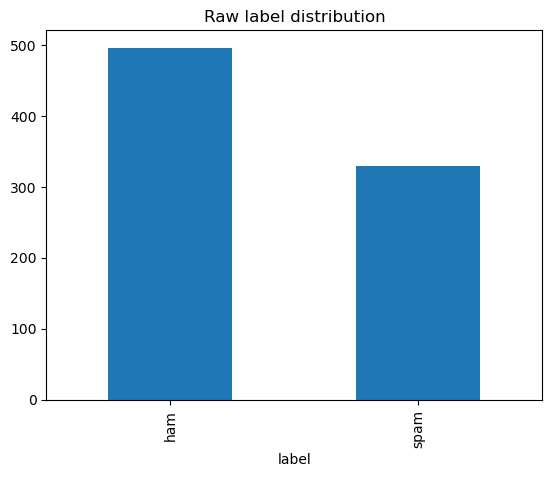

In [5]:
df["label"].value_counts().plot.bar(title="Raw label distribution");

## 2. Transform

### 2-1. Strip outer quotes

Strip the CSV quoting characters (`"`) that wrap the text.

In [6]:
def strip_outer_quotes(t: str) -> str:
    t = t.strip()
    if len(t) >= 2 and t.startswith('"') and t.endswith('"'):
        t = t[1:-1].strip()
    return t

df["text"] = df["text"].map(strip_outer_quotes)

### 2-2. Restore/remove control characters

The text contains Windows-1252 control characters (`U+0080`–`U+009F`)
(e.g., `U+0085` → ellipsis, `U+0091/U+0092` → single quotes, `U+0093/U+0094` → double quotes).
Restore them to the proper symbols and replace the remaining C0/C1 control characters with spaces.

In [7]:
CP1252_CONTROLS = {
    0x80: "€", 0x82: "‚", 0x83: "ƒ", 0x84: "„", 0x85: "…", 0x86: "†", 0x87: "‡",
    0x88: "ˆ", 0x89: "‰", 0x8A: "Š", 0x8B: "‹", 0x8C: "Œ", 0x8E: "Ž",
    0x91: "‘", 0x92: "’", 0x93: "“", 0x94: "”", 0x95: "•", 0x96: "–",
    0x97: "—", 0x98: "˜", 0x99: "™", 0x9A: "š", 0x9B: "›", 0x9C: "œ",
    0x9E: "ž", 0x9F: "Ÿ",
}

def fix_control_chars(t: str) -> str:
    t = t.translate(CP1252_CONTROLS)
    return re.sub(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f-\x9f]", " ", t)

df["text"] = df["text"].map(fix_control_chars)

### 2-3. Normalize whitespace

In [8]:
def normalize_whitespace(t: str) -> str:
    return re.sub(r"\s+", " ", t).strip()

df["text"] = df["text"].map(normalize_whitespace)

### 2-4. Drop empty texts

In [9]:
n_empty = int((df["text"].str.len() == 0).sum())
if n_empty:
    print("Removed", n_empty, "empty texts")
    df = df[df["text"].str.len() > 0].reset_index(drop=True)

Removed 1 empty texts


### 2-5. Clean HTML/boilerplate → `text_clean`

The body contains large amounts of HTML tags, quoted-printable encodings (`=c4`, etc.), URLs, emails, and entities.
We remove/restore them to create a `text_clean` column with text only.

1. Merge split quoted-printable pairs (`=c4 =b0` → `=c4=b0`) and decode
2. Remove HTML tags/entities
3. Remove URLs and emails
4. Remove leftover `=XX` remnants

In [10]:
QP_PAIR  = re.compile(r"=([0-9a-fA-F]{2})\s+=([0-9a-fA-F]{2})")
TAG      = re.compile(r"<[^>]*>")
ENTITY   = re.compile(r"&(?:nbsp|amp|quot|lt|gt|#\d+);?")
URL      = re.compile(r"https?://\S+|www\.\S+")
MAIL     = re.compile(r"\S+@\S+")
QP_LEFT  = re.compile(r"=[0-9a-fA-F]{2}")

def clean_boilerplate(t: str) -> str:
    t = QP_PAIR.sub(r"=\1=\2", t)
    try:
        t = quopri.decodestring(t.encode("utf-8")).decode("utf-8")
    except Exception:
        pass
    t = TAG.sub(" ", t)
    t = html.unescape(t)
    t = ENTITY.sub(" ", t)
    t = URL.sub(" ", t)
    t = MAIL.sub(" ", t)
    t = QP_LEFT.sub(" ", t)
    return re.sub(r"\s+", " ", t).strip()

df["text_clean"] = df["text"].map(clean_boilerplate)

In [11]:
n_lost = int((df["text_clean"].str.len() == 0).sum())
print("Empty after cleaning:", n_lost, "text(s) -> removed")
df = df[df["text_clean"].str.len() > 0].reset_index(drop=True)

Empty after cleaning: 6 text(s) -> removed


### 2-6. Drop duplicates

The same body repeats multiple times (spam template reuse).
Duplicates with conflicting labels only print a warning and keep the label of the first occurrence.

In [12]:
dup_counts = df["text_clean"].value_counts()
print("Unique text ratio:", f"{dup_counts.shape[0]}/{len(df)}")

conflicts = df.groupby("text_clean")["label"].nunique()
n_conflict = int((conflicts > 1).sum())
if n_conflict:
    print("Label-conflicting texts:", n_conflict, "case(s) ->", conflicts[conflicts > 1].index.tolist())

df = df.drop_duplicates(subset="text_clean", keep="first").reset_index(drop=True)
print("After dropping duplicates:", len(df), "records")

Unique text ratio: 731/818
Label-conflicting texts: 1 case(s) -> ['İyi günler benim adım Mehmet. Üniversite öğrencisiyim. Üniversitelerdekimarketlerle alakalı bir araştırma yapıyorum, sizden rica etsemüniversitenizde (varsa eğer) bulunan market ve mağazaların isimlerini mailatabilir misiniz? İlgilenirseniz sevinirim.']
After dropping duplicates: 731 records


### 2-7. Label encoding & derived columns

- `spam` → 1, `ham` → 0
- Turkish-aware lowercasing (`İ`→`i`, `I`→`ı`, then `.lower()`)
- Add feature columns such as length and word count

In [13]:
df["label"] = df["label"].map({"spam": 1, "ham": 0}).astype("int8")

TR_LOWER = str.maketrans("İI", "iı")
df["text_lower"] = df["text_clean"].map(lambda t: t.translate(TR_LOWER).lower())

df["text_len"]   = df["text_lower"].str.len().astype("int32")
df["word_count"] = df["text_lower"].str.split().str.len().astype("int32")

df = df[["label", "text", "text_clean", "text_lower", "text_len", "word_count"]]
df.head(3)

,label,text,text_clean,text_lower,text_len,word_count
0,1,"Sayın Yetkili , Gelişen ve değişen günümüz tek...","Sayın Yetkili , Gelişen ve değişen günümüz tek...","sayın yetkili , gelişen ve değişen günümüz tek...",1530,180
1,1,"Sayın Yetkili, 28 Kasım 2010 tarihli KPSS sına...","Sayın Yetkili, 28 Kasım 2010 tarihli KPSS sına...","sayın yetkili, 28 kasım 2010 tarihli kpss sına...",613,77
2,1,"Sayın Yetkili , Gelişen ve değişen günümüz tek...","Sayın Yetkili , Gelişen ve değişen günümüz tek...","sayın yetkili , gelişen ve değişen günümüz tek...",1532,180


,count,mean,std,min,25%,50%,75%,max
label,731.0,0.340629,0.474245,0.0,0.0,0.0,1.0,1.0
text_len,731.0,1911.547196,2569.766920,2.0,461.5,1067.0,2482.0,20767.0
word_count,731.0,259.845417,431.015541,1.0,53.0,133.0,320.0,4730.0


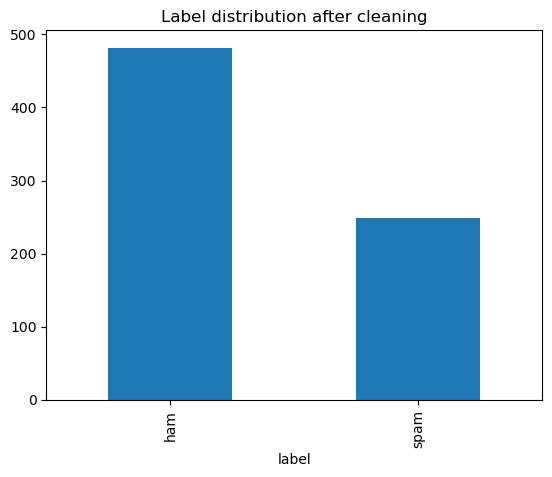

In [14]:
df["label"].value_counts().rename(index={1: "spam", 0: "ham"}).plot.bar(title="Label distribution after cleaning");
df.describe().T

## 3. Load

Split into train/valid/test = 8:1:1 via stratified sampling and save.

In [15]:
train, rest = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df["label"])
valid, test = train_test_split(rest, test_size=0.5, random_state=SEED, stratify=rest["label"])

for name, part in [("train", train), ("valid", valid), ("test", test)]:
    print(name, len(part), "records, spam ratio:", round(float(part["label"].mean()), 3))

train 584 records, spam ratio: 0.341
valid 73 records, spam ratio: 0.342
test 74 records, spam ratio: 0.338


In [16]:
CLEAN_CSV = OUT_DIR / "trspam_clean.csv"
CLEAN_PQT = OUT_DIR / "trspam_clean.parquet"

df.to_csv(CLEAN_CSV, index=False, encoding="utf-8-sig")
try:
    df.to_parquet(CLEAN_PQT, index=False)
    print("parquet saved")
except Exception as e:
    print("parquet save failed:", e)

for name, part in [("train", train), ("valid", valid), ("test", test)]:
    part.to_csv(OUT_DIR / f"trspam_{name}.csv", index=False, encoding="utf-8-sig")

print("Saved ->", OUT_DIR)

parquet saved
Saved -> C:\Users\USER\OneDrive\Desktop\[20.08.26] Light rain\00.turkish+spam


## 4. Verification

Re-read the saved files to verify the ETL result.

In [17]:
check = pd.read_csv(CLEAN_CSV, encoding="utf-8-sig")
print("Rows/cols:", check.shape)
print("Missing values:", int(check.isna().sum().sum()))
print("Label distribution:", check["label"].value_counts().to_dict())

all_text = " ".join(check["text_clean"].str.lower())
print("Remaining HTML tags:", len(re.findall(r"<[a-z/][^>]*>", all_text)))
print("Remaining quoted-printable:", len(re.findall(r"=[0-9a-fA-F]{2}", all_text)))
print("Remaining URLs:", len(re.findall(r"https?://|www\.", all_text)))

assert set(check.columns) == {"label", "text", "text_clean", "text_lower", "text_len", "word_count"}
assert check.isna().sum().sum() == 0
print("Verification passed")

Rows/cols: (731, 6)
Missing values: 0
Label distribution: {0: 482, 1: 249}
Remaining HTML tags: 1
Remaining quoted-printable: 0
Remaining URLs: 0
Verification passed
